In [1]:
%matplotlib widget
# Add the directory containing the package to sys.path
import sys
import numpy as np
from numpy import pi, cos, sin
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
np.set_printoptions(precision=2, suppress=True)
# Enable LaTeX rendering
plt.rc('text', usetex=True)
# Improve resolution
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

In [2]:
#Vitesse du son au moment de la mesure, dependant de la temperature:
Tc = 21.5 
C = np.sqrt( 1.4 * 287 *(Tc + 273) )
Path = './'
NbMems = 256
NbViolTot = 6
NbViol = 6
Dyn = 60

NumViolon = np.load('./../results/NumViolon.npz')['NumViolon']
XYZViolins = np.load('./../results/XYZViolinsAligned.npy')

NbMics = 256
NbSrcs = XYZViolins.shape[0] - NbMics

XYZHammerImpact = XYZViolins[NbSrcs-1]
XYZ = XYZViolins-XYZHammerImpact
XYZs = XYZ[:NbSrcs-1]
XYZm = XYZ[NbSrcs:]
XYZHammerImpact = XYZ[NbSrcs-1]

In [3]:
# Violin positioning
# Define rotation functions locally to avoid dependency issues
def x_rotate_coordinates(coords, a):
    R_x = np.array([
        [1, 0, 0],
        [0, np.cos(a), -np.sin(a)],
        [0, np.sin(a), np.cos(a)]
    ])
    return np.dot(R_x, coords)

def y_rotate_coordinates(coords, a):
    R_y = np.array([
        [np.cos(a), 0, np.sin(a)],
        [0, 1, 0],
        [-np.sin(a), 0, np.cos(a)]
    ])
    return np.dot(R_y, coords)

def z_rotate_coordinates(coords, a):
    R_z = np.array([
        [np.cos(a), -np.sin(a), 0],
        [np.sin(a), np.cos(a), 0],
        [0, 0, 1]
    ])
    return np.dot(R_z, coords)

import trimesh
#Dimensions hors tout du violon Stradivarius Willemotte 1732, d'apres les mesures de Sacconi:
Wv = 206.5e-3  # Convert mm to meters
Lv = 485.7e-3
Hv = 94.7e-3

mesh = trimesh.load('../src/Meshes/violin.ply')  # Can also load .obj or .mtl files
# Extract vertices and faces
vertices = mesh.vertices
vertices -= vertices.mean(axis=0)
rx = 90 * pi/180 
ry = 0 * pi/180 
rz = -90 * pi/180
vertices = x_rotate_coordinates(vertices.T,    rx).T
vertices = y_rotate_coordinates(vertices.T,    ry).T
vertices = z_rotate_coordinates(vertices.T,    rz).T

Dims0 = vertices.max(axis=0) - vertices.min(axis=0)
DimsV = np.array([Hv, Wv, Lv])

Scale = DimsV / Dims0
print(Dims0, DimsV, Scale)
vertices *= Scale

SommetChevalet = vertices[np.abs(vertices[:,0]).argmax()]
print(SommetChevalet)

vertices -= SommetChevalet

print(SommetChevalet)

faces = mesh.faces



[1.24 2.26 6.66] [0.09 0.21 0.49] [0.08 0.09 0.07]
[-0.05 -0.   -0.14]
[0. 0. 0.]


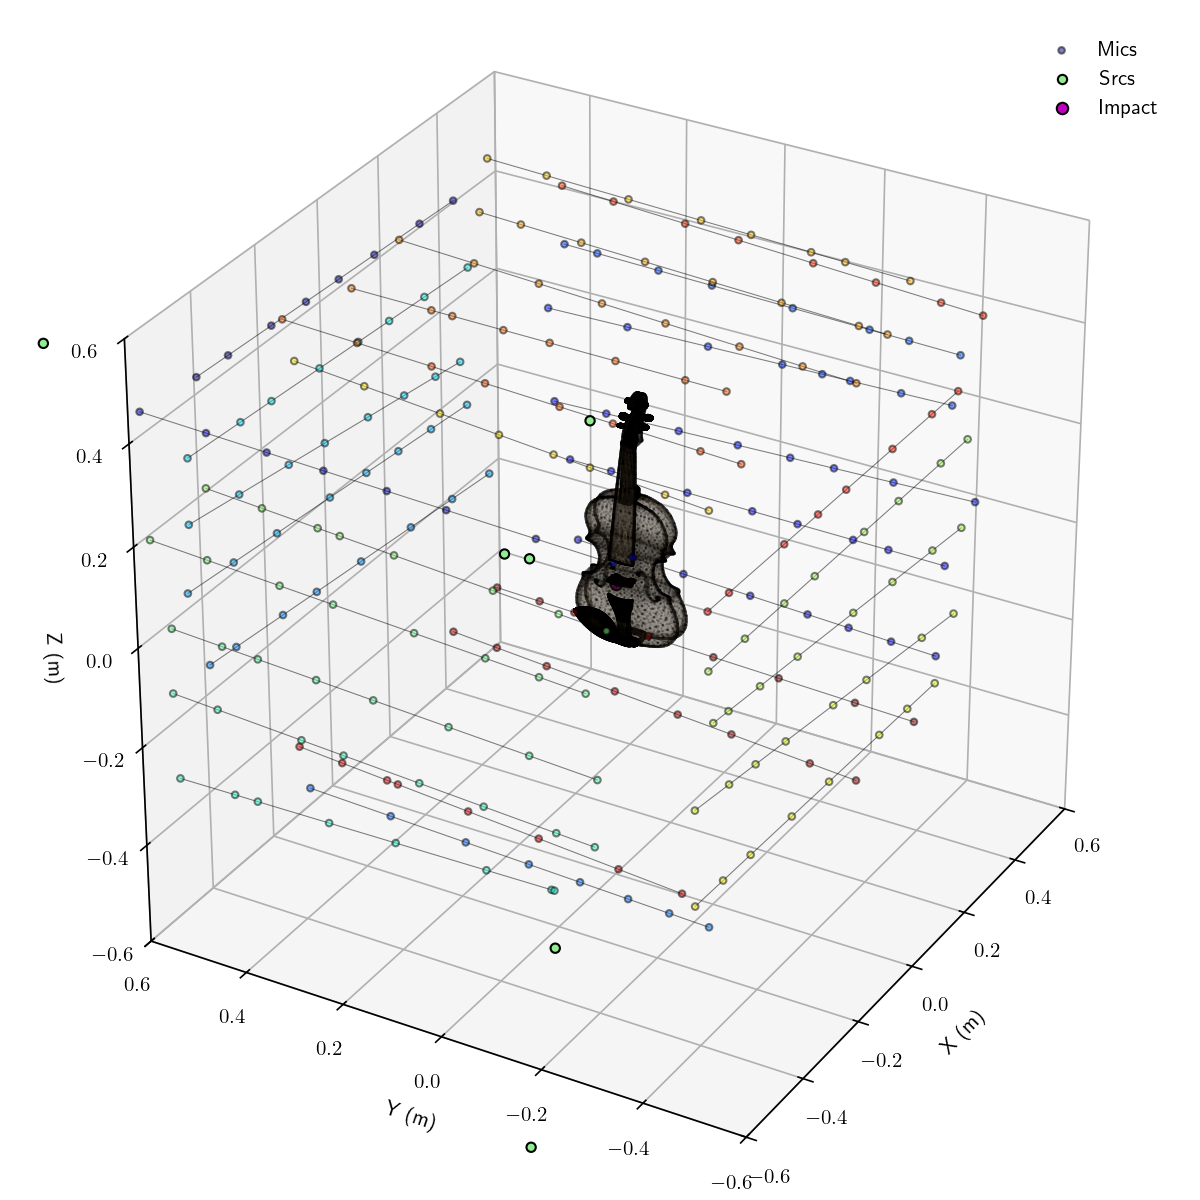

In [4]:
fig = plt.figure(1, figsize=(8, 8))
ax2 = fig.add_subplot(111, projection='3d')
ax2.scatter(*XYZm.T, c =np.arange(NbMics), marker='o',edgecolor='k', s=10, cmap='jet',alpha = 0.5, label = 'Mics')
ax2.scatter(*XYZs.T, marker='o',facecolor ='lightgreen',edgecolor='k', s=20, alpha=1, label = 'Srcs')
ax2.scatter(*XYZHammerImpact.T, marker = 'o', facecolor ='m', edgecolor='k', s=30 ,label='Impact')

for i in range(0, NbMics, 8):
    ax2.plot(XYZm[i:i+8,0], XYZm[i:i+8,1], XYZm[i:i+8,2], color='k', linewidth=0.5, alpha=0.5)

#ax2.set_label([str(i) for i in NumF])
ax2.legend()  
L = 0.6
ax2.set_xlim([-L,L])
ax2.set_ylim([-L,L])
ax2.set_zlim([-L,L])
ax2.set_aspect('equal')

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

light_brown = (0.87, 0.72, 0.53)  # RGB values for light brown
mesh_collection = Poly3DCollection(vertices[faces], alpha=0.1, edgecolor='k', facecolor=light_brown)
ax2.add_collection3d(mesh_collection)
# Set labels
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_zlabel('Z (m)')

ax2.view_init(elev=30, azim=210, roll=0) 
ax2.dist = 0.1  
ax2.legend(loc='upper right', fontsize=10, frameon=False)
plt.tight_layout()
# Show the plot
plt.show()

In [5]:

# 3D Visualization using pythreejs
try:
    from pythreejs import *
    from IPython.display import display
except ImportError:
    print("pythreejs is not installed. Please install it using: %pip install pythreejs")

if 'pythreejs' in sys.modules:
    # Helper to create BufferAttribute
    def make_buffer_attr(array):
        return BufferAttribute(array=array.astype(np.float32, copy=False))

    scene_children = []

    # Microphones (Mics) - Blue Spheres
    mics_geo = SphereGeometry(radius=0.0075, widthSegments=8, heightSegments=8)
    mics_mat = MeshLambertMaterial(color='blue')
    for pos in XYZm:
        scene_children.append(Mesh(geometry=mics_geo, material=mics_mat, position=pos.tolist()))

    # Sources (Srcs) - Green Spheres
    srcs_geo = SphereGeometry(radius=0.01, widthSegments=8, heightSegments=8)
    srcs_mat = MeshLambertMaterial(color='lightgreen')
    for pos in XYZs:
        scene_children.append(Mesh(geometry=srcs_geo, material=srcs_mat, position=pos.tolist()))

    # Impact - Magenta Sphere
    impact_geo = SphereGeometry(radius=0.015, widthSegments=16, heightSegments=16)
    impact_mat = MeshLambertMaterial(color='magenta')
    scene_children.append(Mesh(geometry=impact_geo, material=impact_mat, position=XYZHammerImpact.tolist()))

    # Lines connecting mics in chunks of 8
    line_positions = []
    for i in range(0, NbMics, 8):
        # Create segments (0,1), (1,2), ..., (6,7)
        for j in range(7):
            if i + j + 1 < NbMics:
                line_positions.append(XYZm[i+j])
                line_positions.append(XYZm[i+j+1])
    
    line_positions = np.array(line_positions)
    if len(line_positions) > 0:
        lines_geo = BufferGeometry(attributes={'position': make_buffer_attr(line_positions)})
        lines_mat = LineBasicMaterial(color='black', linewidth=1, transparent=True, opacity=0.5)
        lines = LineSegments(geometry=lines_geo, material=lines_mat)
        scene_children.append(lines)

    # Violin Mesh
    if 'vertices' in locals() and 'faces' in locals():
        # Faces must be flattened for index
        faces_flat = faces.flatten().astype(np.uint32)
        
        mesh_geo = BufferGeometry(
            attributes={
                'position': make_buffer_attr(vertices),
                'index': BufferAttribute(array=faces_flat, itemSize=1)
            }
        )
        
        # Simple light brown material
        # Note: For proper lighting, normals are needed. 
        # We can try to rely on pythreejs/threejs computing them or use basic material if it looks bad.
        # MeshLambertMaterial requires normals. MeshBasicMaterial does not but has no shading.
        # Let's try to add normals if we can, or use double side.
        
        # Adding a helper to compute normals (requires knowing structure, usually handled by three.js helper but pythreejs is low level)
        # We'll use MeshLambert and hope for the best, or create normals via trimesh if possible.
        # vertices are already modified, normals need to be recomputed.
        
        # Re-computing normals using trimesh relative to the transformed vertices
        # We can create a temporary trimesh object to compute vertex normals
        try:
            tm_mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
            tm_mesh.fix_normals()
            normals = tm_mesh.vertex_normals
            mesh_geo.attributes['normal'] = make_buffer_attr(normals)
        except:
             pass 

        mesh_mat = MeshLambertMaterial(color='#DEB887', transparent=True, opacity=0.75, side='DoubleSide')
        violin_mesh = Mesh(geometry=mesh_geo, material=mesh_mat)
        scene_children.append(violin_mesh)

        # Add mesh edges (wireframe)
        wireframe_geo = WireframeGeometry(geometry=mesh_geo)
        wireframe_mat = LineBasicMaterial(color='black', linewidth=1, transparent=True, opacity=0.2)
        wireframe = LineSegments(geometry=wireframe_geo, material=wireframe_mat)
        scene_children.append(wireframe)

    # Scene
    scene = Scene(children=scene_children)

    # Lights
    key_light = DirectionalLight(color='white', position=[5, 5, 10], intensity=0.8)
    fill_light = DirectionalLight(color='white', position=[-5, 0, 5], intensity=0.5)
    amb_light = AmbientLight(color='#777777')
    scene.add([key_light, fill_light, amb_light])

    # Camera
    camera = PerspectiveCamera(position=[-1,1,1], up=[0, 0, 1], aspect=1.0, fov=50)
    camera.lookAt([0, 0, 0])

    # Controls
    controls = OrbitControls(controlling=camera)
    
    # Renderer with square aspect ratio (800x800)
    renderer = Renderer(camera=camera, scene=scene, controls=[controls], width=800, height=800)
    display(renderer)

Renderer(camera=PerspectiveCamera(position=(-1.0, 1.0, 1.0), projectionMatrix=(1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0…

## Investigate the Spherical Harmonics Spectra for each Violin

In [6]:
Cmn = np.load(f'./../results/Optimized_Cmn_and_Diag.npz')['Ref_C']
Diag = np.load(f'./../results/Optimized_Cmn_and_Diag.npz')['Ref_Diag']
Dirs = np.load(f'./../results/Optimized_Cmn_and_Diag.npz')['angles_look']

NbDirs = Dirs.shape[0]
NbTh, NbPh = len(np.unique(Dirs[:,0])), len(np.unique(Dirs[:,1]))
k_vect= np.load(f'./../results/Optimized_Cmn_and_Diag.npz')['kvect']
frq = k_vect * C / (2*pi)
frqMax = frq[-1]
OSH = int(Cmn.shape[1]**0.5 - 1)
NbSH = (OSH+1)**2

In [7]:
OSHSpec = []
no = 0
for o in range(OSH+1):
    sho = np.arange(2*o+1) + no
    no = sho[-1]+1
    OSHSpec.append(np.abs(np.sum(Cmn[:,sho,:], axis = 1))**2)
OSHSpec = np.rollaxis(np.array(OSHSpec),1,0)
OSHSpecN = OSHSpec/np.max(OSHSpec, axis = (1,2))[:,None,None]
OSHSpecdB = 10*np.log10(OSHSpec/np.max(OSHSpec))
OSHSpecdBmax = np.max(OSHSpecdB)

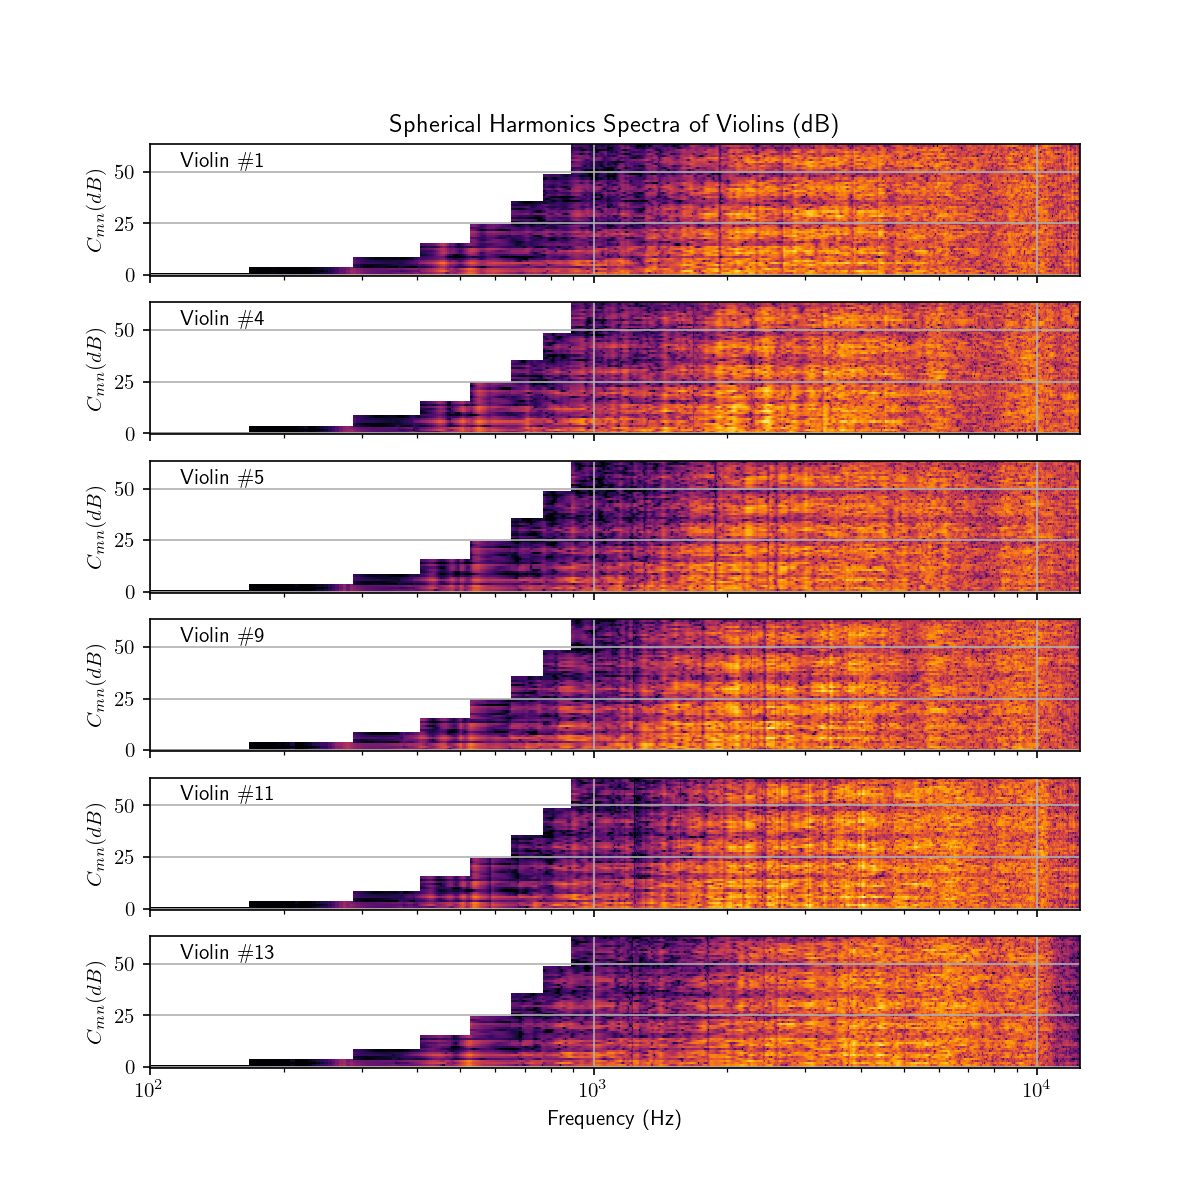

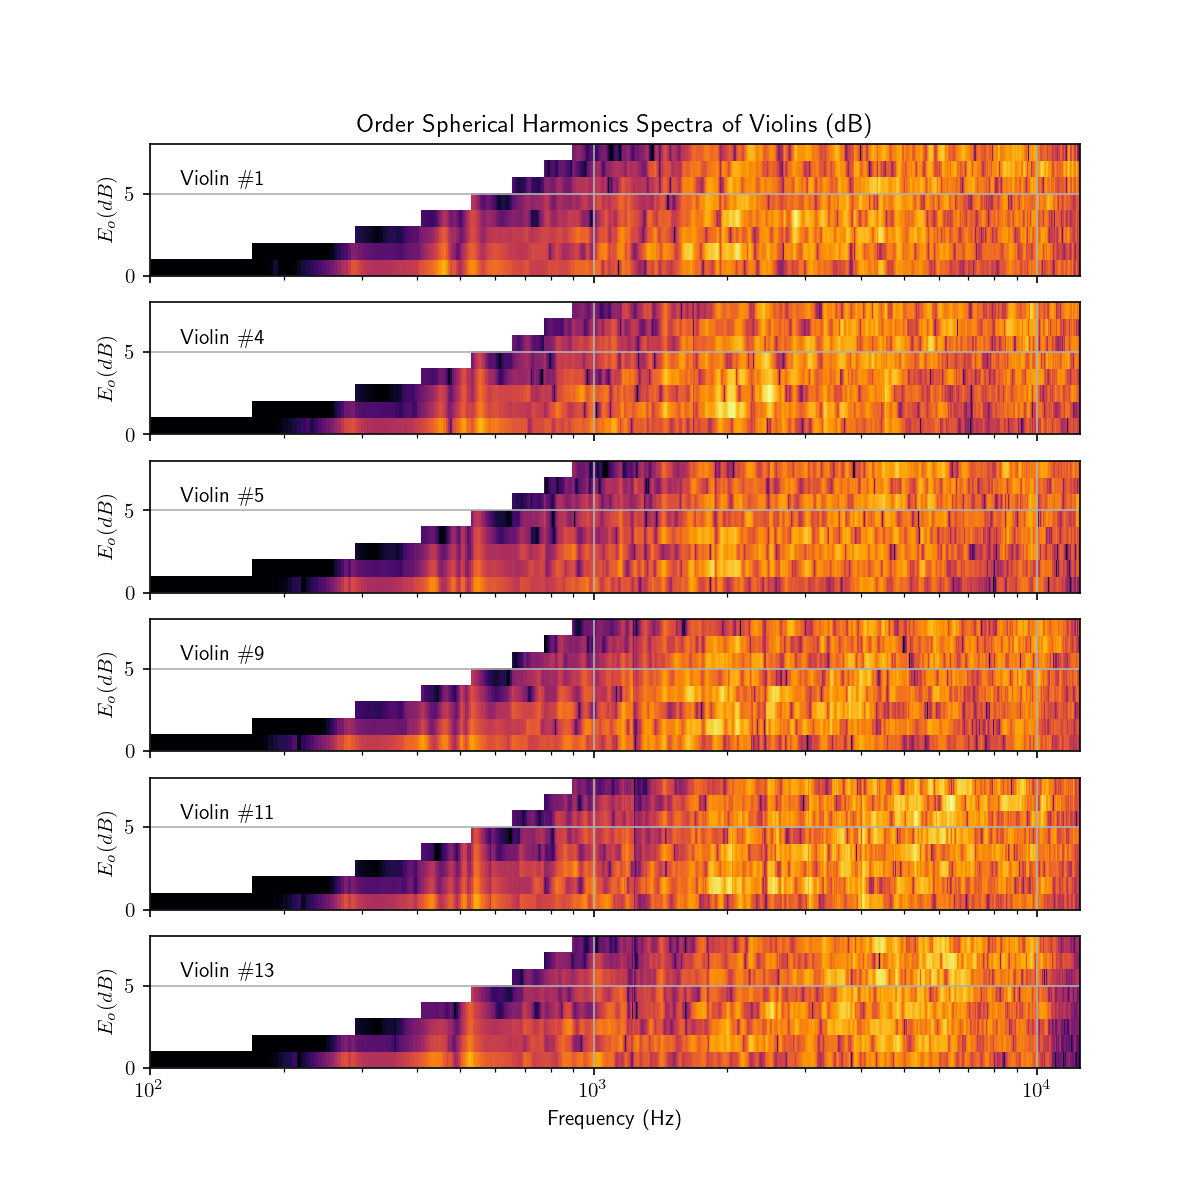

In [8]:
CmndB = 20*np.log10(np.abs(Cmn)/np.max(np.abs(Cmn)))
CmndBmax = np.max(CmndB)
NumViolon = [1, 4, 5, 9, 11, 13]  # Violons a analyser

figH,axH = plt.subplots(NbViol,1,figsize=(8,8))
figO,axO = plt.subplots(NbViol,1,figsize=(8,8))
for v in range(NbViol):
    c = axH[v].pcolor(frq, np.arange(NbSH), CmndB[v,:,:], cmap='inferno', shading='nearest', vmin=CmndBmax-Dyn, vmax=CmndBmax)    
    axH[v].set_ylabel('$C_{mn} (dB)$')
    axH[v].grid()    
    axH[v].set_xscale('log')
    axH[v].set_xlim([100,frqMax])
    axH[v].annotate(f"Violin \#{NumViolon[v]:d}", xy=(105, 52.5), xytext=(10, 0), textcoords='offset points')
    if v < NbViol-1:
        axH[v].set_xticklabels([])
    else:    
        axH[v].set_xlabel('Frequency (Hz)')     
    if not v : 
        axH[v].set_title('Spherical Harmonics Spectra of Violins (dB)')   
        #fig.colorbar(c, ax[v]) 
    X = np.arange(frq[0],frq[-1]+2*(frq[1]-frq[0]),frq[1]-frq[0])
    c = axO[v].pcolor(X, np.arange(OSH+2), OSHSpecdB[v,:,:], cmap='inferno', shading='flat', vmin=OSHSpecdBmax-Dyn, vmax=OSHSpecdBmax)    
    axO[v].set_ylabel('$E_o (dB)$')
    axO[v].grid()    
    axO[v].set_xscale('log')
    axO[v].set_xlim([100,frqMax])
    axO[v].annotate(f"Violin \#{NumViolon[v]:d}", xy=(105, 5.5), xytext=(10, 0), textcoords='offset points')
    if v < NbViol-1:
        axO[v].set_xticklabels([])
    else:    
        axO[v].set_xlabel('Frequency (Hz)')     
    if not v : 
        axO[v].set_title('Order Spherical Harmonics Spectra of Violins (dB)')   
        #fig.colorbar(c, ax[v]) 
#fig.tight_layout()

Global max of |Diag| (99.9%): 1.5934e+02
Absolute max of |Diag|: 4.4051e+02


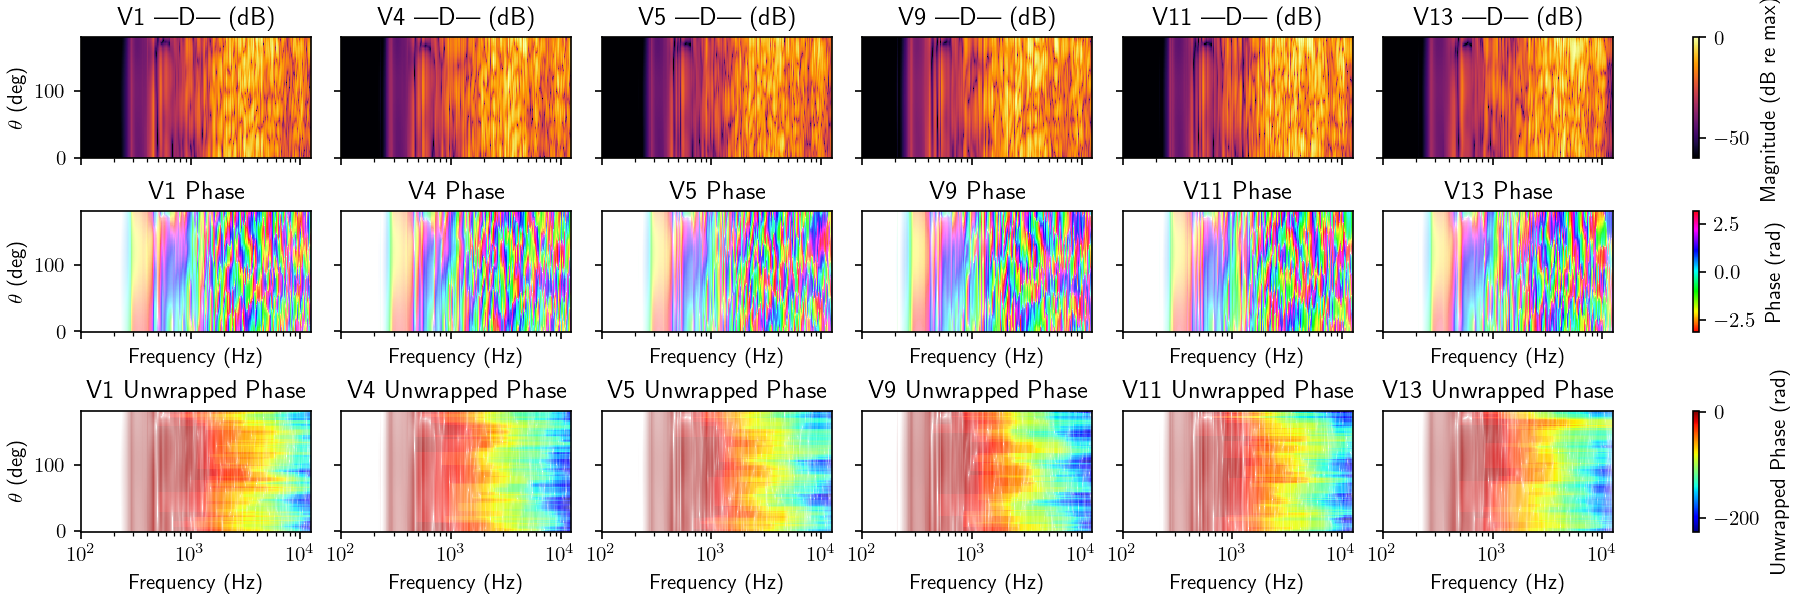

In [9]:
# Compute global maximum of the magnitude across all data (Violins, Angles, Frequencies)
# Use percentile to exclude outliers (e.g. 99.9%)
GlobMax = np.percentile(np.abs(Diag), 99.9)
print(f"Global max of |Diag| (99.9%): {GlobMax:.4e}")
print(f"Absolute max of |Diag|: {np.max(np.abs(Diag)):.4e}")

# Normalize and convert to dB
DiagdB = 20*np.log10(np.abs(Diag)/GlobMax)

# Clip outliers to 0 dB for visualization consistency
DiagdB[DiagdB > 0] = 0

# Build a first row of heatmaps where, for each violin, in the plane phi=0, 
# The magnitude of Diag in dB is plotted with the colormap inferno and a 30dB dynamics, theta versus frequency.
# A second row represents the phase of Diag using the hsv colormap.
# A third row represents the unwrapped phase of Diag.

# 1. Identify indices for phi ~ 0
phi_values = Dirs[:, 1]
# Find the phi value closest to 0
target_phi = 0
closest_phi = phi_values[np.argmin(np.abs(phi_values - target_phi))]
phi0_mask = np.isclose(phi_values, closest_phi)
phi0_indices = np.where(phi0_mask)[0]

# Sort indices by theta to ensure correct plotting order
sorted_idx_idx = np.argsort(Dirs[phi0_indices, 0])
phi0_indices = phi0_indices[sorted_idx_idx]
thetas_deg = Dirs[phi0_indices, 0] * 180 / np.pi

# 2. Plotting
fig, axes = plt.subplots(3, NbViol, figsize=(NbViol*2, 4), sharex=True, sharey=True, constrained_layout=True)

# Pre-compute colormap for phase to RGBA mapping
cmap_phase = plt.cm.hsv
norm_phase = plt.Normalize(-np.pi, np.pi)

# Create a ScalarMappable for the Phase colorbar
sm_phase = plt.cm.ScalarMappable(cmap=cmap_phase, norm=norm_phase)
sm_phase.set_array([])

pcm_mag_list = [] # Store pcm objects for colorbar (using first one is fine usually)
pcm_unwrapped_list = []

for v in range(NbViol):
    # Slice Diag for the specific violin and phi=0 plane
    # Diag shape: (NbViol, NbDirs, Nbf)
    DgdB_slice = DiagdB[v, phi0_indices, :]  # Shape: (NbTh_slice, Nbf)
    DgPh_slice = np.angle(Diag[v, phi0_indices, :])  # Shape: (NbTh_slice, Nbf)
    
    # --- Magnitude Plot (Row 0) ---
    ax_mag = axes[0, v]
    # Use pcolormesh. f is frequency, thetas_deg is theta. 
    pcm_mag = ax_mag.pcolormesh(frq, thetas_deg, DgdB_slice, cmap='inferno', vmin=-Dyn, vmax=0, shading='auto')
    pcm_mag_list.append(pcm_mag)
    
    ax_mag.set_title(f'V{NumViolon[v]} |D| (dB)')
    ax_mag.set_xscale('log')
    ax_mag.set_xlim(100, frqMax)
    if v == 0:
        ax_mag.set_ylabel(f'$\\theta$ (deg)')

    # --- Phase Plot (Row 1) with Transparency based on Magnitude ---
    Phase = DgPh_slice
    Mag_dB = DgdB_slice

    ax_ph = axes[1, v]
    
    # Create the mesh with phase data initially
    pcm_ph = ax_ph.pcolormesh(frq, thetas_deg, Phase, cmap='hsv', vmin=-np.pi, vmax=np.pi, shading='auto')
    
    # 1. Map Phase to RGBA colors
    phase_colors = cmap_phase(norm_phase(Phase)) # Shape: (NbTh_slice, Nbf, 4)

    # 2. Compute Alpha from Magnitude
    # Linear mapping: -Dyn dB -> alpha=0, 0 dB -> alpha=1
    alpha = (Mag_dB - (-Dyn)) / (0 - (-Dyn))
    alpha = np.clip(alpha, 0, 1)

    # 3. Apply alpha to RGBA array
    phase_colors[..., 3] = alpha

    # 4. Update the facecolors of the QuadMesh
    # pcm_ph.set_array(None) ensures the scalar array doesn't override facecolors
    pcm_ph.set_array(None) 
    # Flatten the RGBA array to match the flattened faces
    pcm_ph.set_facecolors(phase_colors.reshape(-1, 4))
    
    ax_ph.set_title(f'V{NumViolon[v]} Phase')
    ax_ph.set_xlabel('Frequency (Hz)')
    ax_ph.set_xscale('log')
    ax_ph.set_xlim(100, frqMax)
    if v == 0:
        ax_ph.set_ylabel(f'$\\theta$ (deg)')
        
    # --- Unwrapped Phase Plot (Row 2) ---
    # Unwrap along frequency axis (axis 1)
    UnwrappedPhase = np.unwrap(DgPh_slice, axis=1)
    
    # Apply transparency to unwrapped phase as well?
    # Usually unwrapped phase is viewed for continuity, transparency might help see structure.
    # The user asked for "unwrapped phases", let's give them the same treatment for consistency.
    
    UwPhase = UnwrappedPhase
    
    ax_unwrapped = axes[2, v]
    # Use a divergent or sequential colormap, e.g., 'viridis' or 'seismic' if centered
    # Since unwrapped phase drifts, 'viridis' is safer.
    
    # Calculate vmin/vmax per violin to maximize contrast as each drifts differently
    umin, umax = UwPhase.min(), UwPhase.max()
    
    pcm_unwrapped = ax_unwrapped.pcolormesh(frq, thetas_deg, UwPhase, cmap='jet', shading='auto') # vmin=umin, vmax=umax implicit
    pcm_unwrapped_list.append(pcm_unwrapped)
    
    # Optional: Apply transparency to Unwrapped Phase
    # 1. Map Unwrapped Phase to RGBA using viridis and its own range
    # Since range varies, we might want to normalize per plot or globally.
    # pcolormesh handles normalization to the data range by default.
    # We can fetch the mapped colors.
    
    # Using the auto-normalized colors from pcolormesh
    # But pcolormesh returns mappable, not RGBA array directly unless we ask.
    # We can replicate the mapping manually.
    norm_uw = plt.Normalize(umin, umax)
    cmap_uw = plt.get_cmap('jet')
    
    uw_colors = cmap_uw(norm_uw(UwPhase))
    uw_colors[..., 3] = alpha # Use same alpha mask
    
    pcm_unwrapped.set_array(None)
    pcm_unwrapped.set_facecolors(uw_colors.reshape(-1, 4))
    
    ax_unwrapped.set_title(f'V{NumViolon[v]} Unwrapped Phase')
    ax_unwrapped.set_xlabel('Frequency (Hz)')
    ax_unwrapped.set_xscale('log')
    ax_unwrapped.set_xlim(100, frqMax)
    if v == 0:
        ax_unwrapped.set_ylabel(f'$\\theta$ (deg)')


fig.colorbar(pcm_mag_list[0], ax=axes[0, :], location='right', label='Magnitude (dB re max)')
fig.colorbar(sm_phase, ax=axes[1, :], location='right', label='Phase (rad)')
# Colorbar for unwrapped phase: Since we applied per-plot normalization (implicit in pcolormesh without vmin/vmax),
# sharing one colorbar is misleading if ranges differ.
# However, usually we want to see the trend. 
# Let's add one, but label it "Unwrapped Phase (rad)" and note it might scale.
# Using the last one plotted.
fig.colorbar(pcm_unwrapped_list[0], ax=axes[2, :], location='right', label='Unwrapped Phase (rad)')

plt.show()

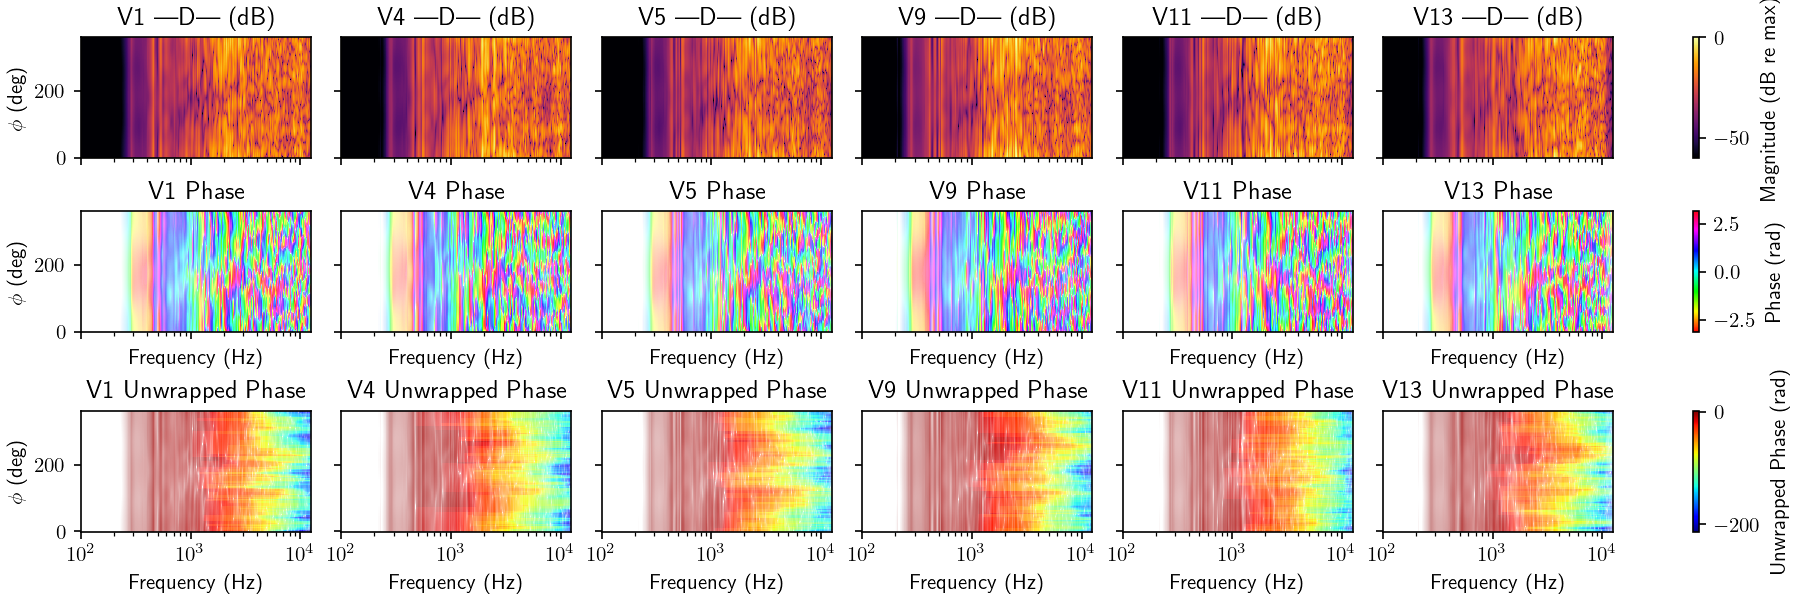

In [10]:
# Equivalent figure for theta = 90 deg (Equatorial plane), phi vs frequency
# Note: Theta=0 corresponds to the North Pole where variation with Phi is zero (singularity).
# We use Theta=pi/2 (90 degrees) to show the equatorial plane.

# 1. Identify indices for theta ~ 90 degrees
theta_values = Dirs[:, 0]
# Find the theta value closest to pi/2
target_theta = np.pi/2
closest_theta = theta_values[np.argmin(np.abs(theta_values - target_theta))]
theta0_mask = np.isclose(theta_values, closest_theta)
theta0_indices = np.where(theta0_mask)[0]

# Sort indices by phi to ensure correct plotting order
sorted_idx_idx = np.argsort(Dirs[theta0_indices, 1])
theta0_indices = theta0_indices[sorted_idx_idx]
phis_deg = Dirs[theta0_indices, 1] * 180 / np.pi

# 2. Plotting
fig, axes = plt.subplots(3, NbViol, figsize=(NbViol*2, 4), sharex=True, sharey=True, constrained_layout=True)

# Ensure GlobalMaxAbs is defined (if running this cell independently)
# Also using DiagdB which is calculated in previous cell.
if 'DiagdB' not in locals():
    print("Warning: DiagdB is not defined. Please run the previous cell first.")
    # Recalculate if needed, but assuming sequential execution.

# Pre-compute colormap for phase to RGBA mapping
cmap_phase = plt.cm.hsv
norm_phase = plt.Normalize(-np.pi, np.pi)

# Create a ScalarMappable for the Phase colorbar
sm_phase = plt.cm.ScalarMappable(cmap=cmap_phase, norm=norm_phase)
sm_phase.set_array([])

pcm_mag_list = []
pcm_unwrapped_list = []

for v in range(NbViol):
    # Slice Diag for the specific violin and theta=90 plane
    DgdB_slice = DiagdB[v, theta0_indices, :]  # Shape: (NbPh_slice, Nbf)
    DgPh_slice = np.angle(Diag[v, theta0_indices, :]) # Shape: (NbPh_slice, Nbf)
    # --- Magnitude Plot (Row 0) ---
    
    ax_mag = axes[0, v]
    # Assuming 'frq' is the frequency vector based on previous cell usage. 'f' was likely a typo or leftover.
    pcm_mag = ax_mag.pcolormesh(frq, phis_deg, DgdB_slice, cmap='inferno', vmin=-Dyn, vmax=0, shading='auto')
    pcm_mag_list.append(pcm_mag)
    
    ax_mag.set_title(f'V{NumViolon[v]} |D| (dB)')
    ax_mag.set_xscale('log')
    ax_mag.set_xlim(100, frqMax)
    if v == 0:
        ax_mag.set_ylabel(f'$\phi$ (deg)')

    # --- Phase Plot (Row 1) with Transparency ---
    Phase = DgPh_slice
    Mag_dB = DgdB_slice
    
    ax_ph = axes[1, v]
    
    # Create the mesh
    pcm_ph = ax_ph.pcolormesh(frq, phis_deg, Phase, cmap='hsv', vmin=-np.pi, vmax=np.pi, shading='auto')
    
    # 1. Map Phase to RGBA colors
    phase_colors = cmap_phase(norm_phase(Phase)) # Shape: (NbPh_slice, Nbf, 4)

    # 2. Compute Alpha from Magnitude
    alpha = (Mag_dB - (-Dyn)) / (0 - (-Dyn))
    alpha = np.clip(alpha, 0, 1)

    # 3. Apply alpha to RGBA array
    phase_colors[..., 3] = alpha

    # 4. Update the facecolors
    pcm_ph.set_array(None)
    pcm_ph.set_facecolors(phase_colors.reshape(-1, 4))
    
    ax_ph.set_title(f'V{NumViolon[v]} Phase')
    ax_ph.set_xlabel('Frequency (Hz)')
    ax_ph.set_xscale('log')
    ax_ph.set_xlim(100, frqMax)
    if v == 0:
        ax_ph.set_ylabel(f'$\phi$ (deg)')

    # --- Unwrapped Phase Plot (Row 2) ---
    # Unwrap along frequency axis (axis 1)
    UnwrappedPhase = np.unwrap(DgPh_slice, axis=1)
    
    UwPhase = UnwrappedPhase
    
    ax_unwrapped = axes[2, v]
    
    # Calculate vmin/vmax per violin
    umin, umax = UwPhase.min(), UwPhase.max()
    
    pcm_unwrapped = ax_unwrapped.pcolormesh(frq, phis_deg, UwPhase, cmap='jet', shading='auto')
    pcm_unwrapped_list.append(pcm_unwrapped)
    
    # 1. Map Unwrapped Phase to RGBA
    norm_uw = plt.Normalize(umin, umax)
    cmap_uw = plt.get_cmap('jet')
    
    uw_colors = cmap_uw(norm_uw(UwPhase))
    uw_colors[..., 3] = alpha # Apply same transparency
    
    pcm_unwrapped.set_array(None)
    pcm_unwrapped.set_facecolors(uw_colors.reshape(-1, 4))
    
    ax_unwrapped.set_title(f'V{NumViolon[v]} Unwrapped Phase')
    ax_unwrapped.set_xlabel('Frequency (Hz)')
    ax_unwrapped.set_xscale('log')
    ax_unwrapped.set_xlim(100, frqMax)
    if v == 0:
        ax_unwrapped.set_ylabel(f'$\phi$ (deg)')


fig.colorbar(pcm_mag_list[0], ax=axes[0, :], location='right', label='Magnitude (dB re max)')
fig.colorbar(sm_phase, ax=axes[1, :], location='right', label='Phase (rad)')
# Colorbar for unwrapped phase
fig.colorbar(pcm_unwrapped_list[0], ax=axes[2, :], location='right', label='Unwrapped Phase (rad)')

plt.show()

Global Max Linear Amplitude (Octave): 2.9816e+03


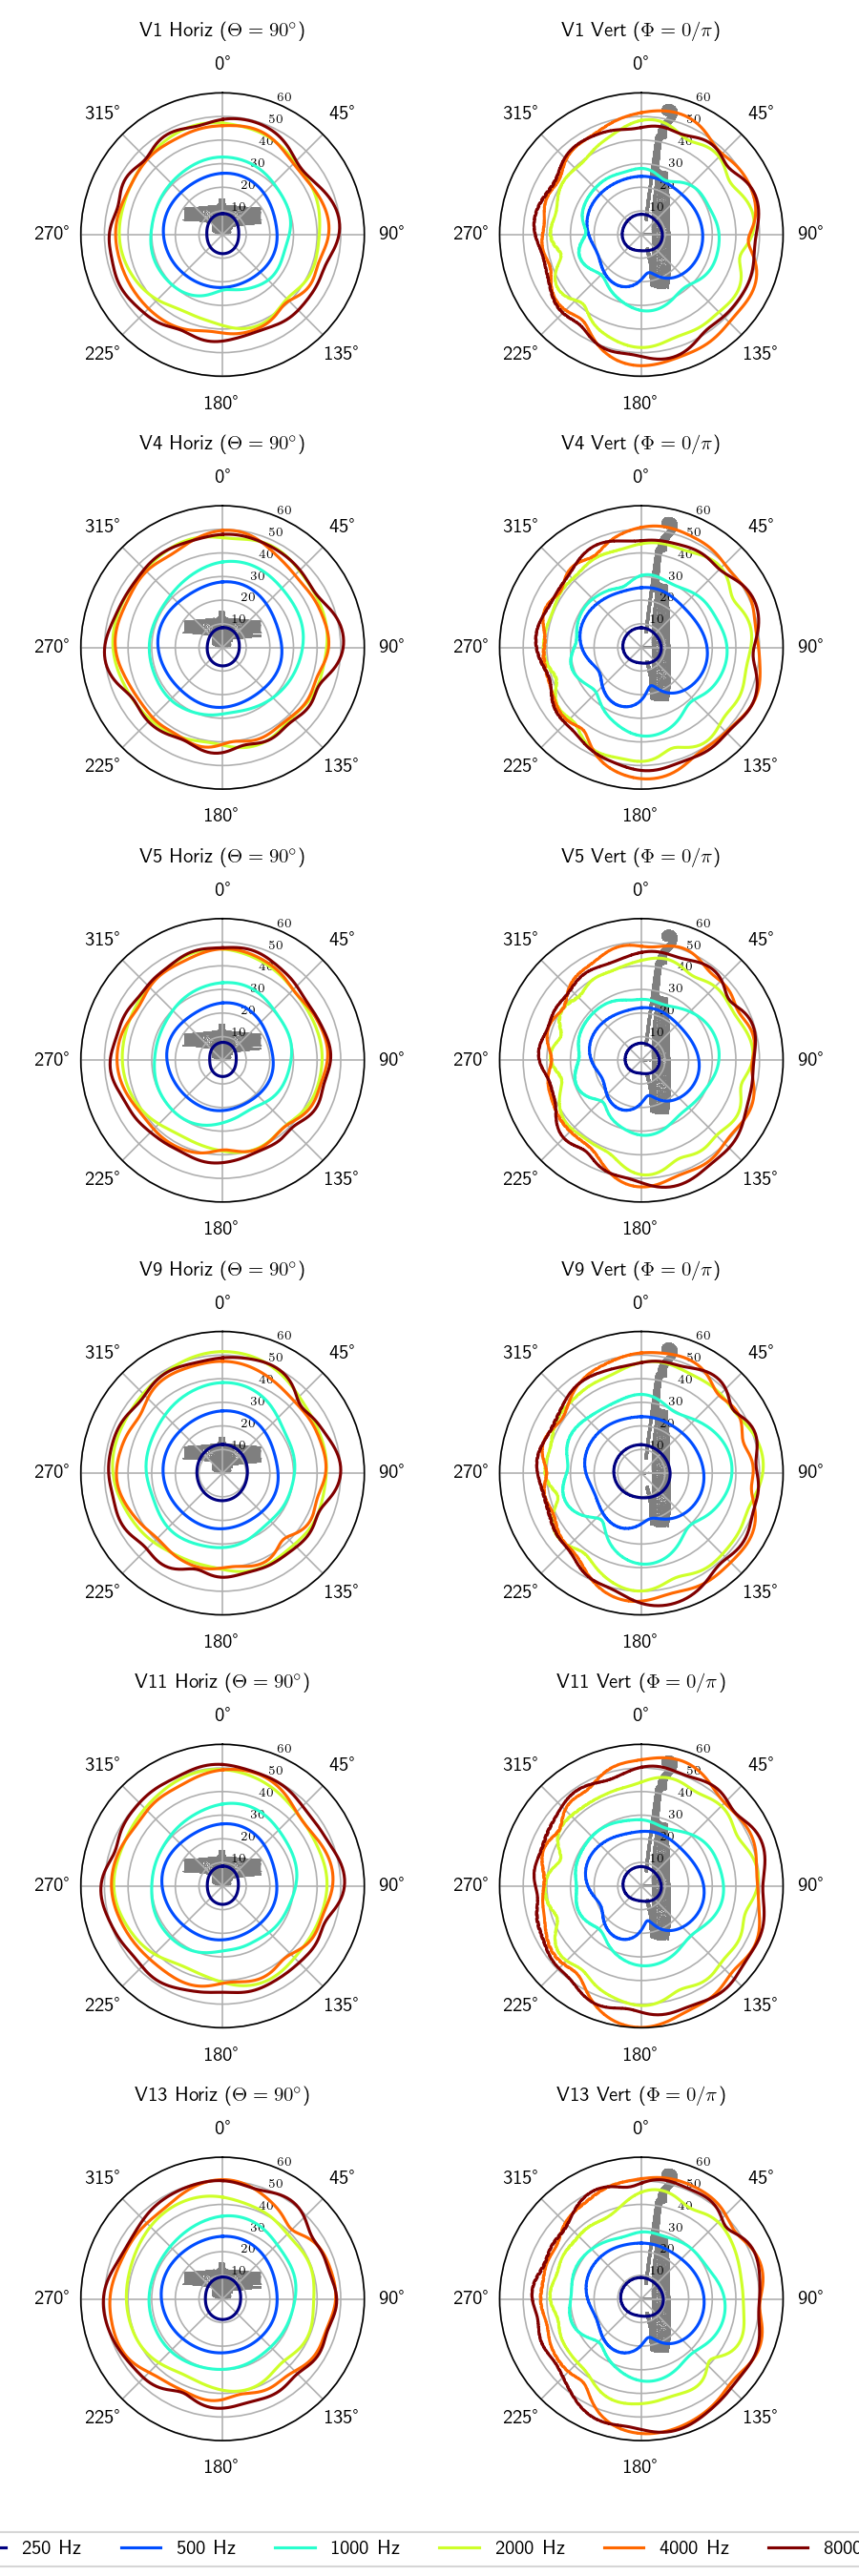

In [ ]:
# Polar plots of DiagdB per Octave Band
# Row 1: Horizontal Plane (Theta = 90 deg)
# Row 2: Vertical Plane (Combined Phi=0 and Phi=pi)


# 1. Define Octave Bands
center_freqs = [250, 500, 1000, 2000, 4000, 8000] # Hz
band_indices = []
for fc in center_freqs:
    fmin = fc / np.sqrt(2)
    fmax = fc * np.sqrt(2)
    indices = np.where((frq >= fmin) & (frq <= fmax))[0]
    if len(indices) > 0:
        band_indices.append((fc, indices))

# 2. Calculate Linear Diag for all Bands first
NbBands_Oct = len(band_indices)
Diag_Band_Oct = np.zeros((NbViol, NbDirs, NbBands_Oct))

for i, (fc, idxs) in enumerate(band_indices):
    # Sum energy in band
    D_slice = Diag[:, :, :][:, :, idxs]
    # Sum of squares magnitude (Energy sum)
    Diag_Band_Oct[:, :, i] = np.sqrt(np.abs(np.sum(D_slice)**2, axis=2))

# 3. Global Max Reference
RefVal = np.max(Diag_Band_Oct)
print(f"Global Max Linear Amplitude (Octave): {RefVal:.4e}")

# Convert to dB
# Range: [max-Dyn, max] -> Shifted to [0, Dyn] for polar radius
Diag_Band_Oct_dB = 20 * np.log10(Diag_Band_Oct / RefVal + 1e-12)
Diag_Band_Oct_dB = np.maximum(Diag_Band_Oct_dB, -Dyn) + Dyn 

# 4. Prepare Indices for planes

# Plane Theta = 90 (Horizontal/Equatorial) -> Function of Phi
target_theta = np.pi/2
closest_theta = theta_values[np.argmin(np.abs(theta_values - target_theta))]
indices_th90 = np.where(np.isclose(theta_values, closest_theta))[0]
sort_th90 = np.argsort(Dirs[indices_th90, 1])
indices_th90 = indices_th90[sort_th90]
angles_ph_th90 = Dirs[indices_th90, 1] 

# Plane Phi = 0 (Vertical/Meridional Front)
target_phi = 0
closest_phi = phi_values[np.argmin(np.abs(phi_values - target_phi))]
indices_ph0 = np.where(np.isclose(phi_values, closest_phi))[0]
sort_ph0 = np.argsort(Dirs[indices_ph0, 0])
indices_ph0 = indices_ph0[sort_ph0]
angles_th_ph0 = Dirs[indices_ph0, 0] # 0 to pi

# Plane Phi = pi (Vertical/Meridional Back)
dist_pi = np.minimum(np.abs(phi_values - np.pi), np.abs(phi_values + np.pi))
indices_ph180 = np.where(np.isclose(dist_pi, np.min(dist_pi)))[0]
sort_ph180 = np.argsort(Dirs[indices_ph180, 0])
indices_ph180 = indices_ph180[sort_ph180]
angles_th_ph180 = Dirs[indices_ph180, 0] # 0 to pi usually

# 5. Create Figure
fig, axes = plt.subplots(NbViol,2, figsize=(6, NbViol*3), subplot_kw={'projection': 'polar'})

colors = plt.cm.jet(np.linspace(0, 1, len(band_indices)))

for v in range(NbViol):
    # --- Row 0: Horizontal Plane (Theta=90) ---
    ax_h = axes[v, 0]
    ax_h.set_title(f'V{NumViolon[v]} Horiz ($\Theta=90^\circ$)', fontsize=10, pad=10)
    
    for i, (fc, idxs) in enumerate(band_indices):
        # Extract pre-calculated dB values
        Mag_dB_plane = Diag_Band_Oct_dB[v, indices_th90, i]

        # Close the loop
        Mag_plot = np.append(Mag_dB_plane, Mag_dB_plane[0])
        Ang_plot = np.append(angles_ph_th90, angles_ph_th90[0] + 2*np.pi) 
        
        ax_h.plot(Ang_plot, Mag_plot, color=colors[i], linewidth=1.5, label=f'{fc} Hz' if v==0 else "")

    ax_h.set_theta_zero_location("N")
    ax_h.set_theta_direction(-1)
    ax_h.set_ylim(0, Dyn)
    ax_h.set_rticks(np.arange(10, Dyn+1, 10))
    ax_h.tick_params(axis='y', labelsize=6)
    ax_h.grid(True, alpha=1)

    if 'vertices' in locals() and 'faces' in locals():
        r_xy = np.hypot(vertices[:,0], vertices[:,1])
        scale_val = 20.0 / (np.max(r_xy) + 1e-12)
        r_xy = r_xy * scale_val
        th_xy = np.arctan2(vertices[:,1], vertices[:,0])
        ax_h.triplot(th_xy, r_xy, triangles=faces, color='k', alpha=0.5, linewidth=0.3)

    # --- Row 1: Vertical Plane (Phi=0 and Phi=pi) ---
    ax_v = axes[v, 1]
    ax_v.set_title(f'V{NumViolon[v]} Vert ($\Phi=0/\pi$)', fontsize=10, pad=10)
    
    for i, (fc, idxs) in enumerate(band_indices):
        # Extract pre-calculated dB values
        Mag_dB_0 = Diag_Band_Oct_dB[v, indices_ph0, i]
        Mag_dB_180 = Diag_Band_Oct_dB[v, indices_ph180, i]
        
        # Combine
        Mag_full = np.concatenate([Mag_dB_0, Mag_dB_180[::-1]])
        Ang_full = np.concatenate([angles_th_ph0, 2*np.pi - angles_th_ph180[::-1]])
        
        # Close loop
        Mag_full = np.append(Mag_full, Mag_full[0])
        Ang_full = np.append(Ang_full, 2*np.pi)
        
        ax_v.plot(Ang_full, Mag_full, color=colors[i], linewidth=1.5, label=f'{fc} Hz' if v==0 else "")

    ax_v.set_theta_zero_location("N")
    ax_v.set_theta_direction(-1)
    ax_v.set_ylim(0, Dyn)
    ax_v.set_rticks(np.arange(10, Dyn+1, 10))
    ax_v.tick_params(axis='y', labelsize=6)
    ax_v.grid(True, alpha=1)

    if 'vertices' in locals() and 'faces' in locals():
        r_xz = np.hypot(vertices[:,0], vertices[:,2])
        r_xz = r_xz * scale_val 
        th_xz = np.arctan2(vertices[:,0], vertices[:,2])
        th_xz = np.where(th_xz < 0, th_xz + 2*np.pi, th_xz)
        ax_v.triplot(th_xz, r_xz, triangles=faces, color='k', alpha=0.5, linewidth=0.3)

# Global Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
# Place legend at bottom, leaving space with tight_layout rect
fig.legend(handles, labels, loc='lower center', ncol=len(band_indices), bbox_to_anchor=(0.5, 0.0), borderaxespad=0.5)

# Adjust layout to make room for legend at bottom
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

In [ ]:
import scipy.spatial
import json
from IPython.display import HTML

# Ensure data is available
if 'Diag' not in locals() or 'vertices' not in locals():
    print("Error: Diag or vertices not defined. Please run previous cells first (especially computation of Diag).")
else:
    # --- Prepare Geometry ---
    # 1. Violin Mesh
    v_verts = vertices.tolist()
    # faces might be trimesh object or array
    v_faces = faces.tolist() if isinstance(faces, np.ndarray) else faces

    # 2. Sphere Mesh (Directivity) from Dirs
    # Dirs: (N, 2) -> Theta, Phi. Assume standard spherical coords (Theta from Z, Phi from X)
    # R = 1 meter
    theta = Dirs[:, 0]
    phi = Dirs[:, 1]
    
    # Convert to Cartesian (Z-up)
    sx = np.sin(theta) * np.cos(phi)
    sy = np.sin(theta) * np.sin(phi)
    sz = np.cos(theta)
    s_points = np.stack([sx, sy, sz], axis=1)
    
    # Compute Convex Hull to get triangulation for these points
    hull = scipy.spatial.ConvexHull(s_points)
    s_faces = hull.simplices.tolist()
    s_verts = s_points.flatten().tolist() # [x0,y0,z0, x1,y1,z1, ...]

    # --- Prepare Data ---
    # Diag: (NbViol, NbDirs, Nbf)
    # We strip Phase, take Magnitude in dB.
    # To reduce data size for the browser, we can decimate frequency if needed.
    
    step_f = 1
    if len(f) > 500:
        step_f = int(len(f) / 500)
    
    f_sub = f[::step_f]
    Diag_sub = Diag[:, :, ::step_f]
    
    # Compute dB
    Mag = np.abs(Diag_sub)
    # Avoid log(0)
    Mag_dB = 20 * np.log10(Mag + 1e-12)
    
    # Transpose for JS: [Violin][Freq][Dir] -> easier to access frame data
    Mag_dB_T = Mag_dB.transpose(0, 2, 1)
    
    # Round to 2 decimals to save JSON space
    diag_data = np.round(Mag_dB_T, 2).tolist()
    freqs_list = np.round(f_sub, 1).tolist()
    
    # --- Generate HTML/JS ---
    html_template = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Violin Directivity</title>
        <style>
            #viz-container {{ width: 100%; height: 600px; position: relative; background: #222; overflow: hidden; }}
            #viz-info {{
                position: absolute; top: 10px; width: 100%; text-align: center;
                color: #eee; font-family: monospace; font-size: 18px; pointer-events: none;
                text-shadow: 1px 1px 2px #000;
            }}
            #viz-gui {{ position: absolute; top: 10px; right: 10px; }}
        </style>
        <!-- Load Three.js and OrbitControls from CDN -->
        <script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
        <script src="https://cdnjs.cloudflare.com/ajax/libs/dat-gui/0.7.7/dat.gui.min.js"></script>
        <script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js"></script>
    </head>
    <body>
        <div id="viz-container">
            <div id="viz-info">Freq: <span id="lbl-freq"></span> Hz</div>
        </div>
        <script>
        (function() {{
            // Encapsulate to avoid global namespace pollution in Notebook
            const container = document.getElementById('viz-container');
            
            // --- DATA ---
            const vVerts = {json.dumps(v_verts)};
            const vFaces = {json.dumps(v_faces)};
            const sVerts = {json.dumps(s_verts)}; // Flattened
            const sFaces = {json.dumps(s_faces)};
            const dataDB = {json.dumps(diag_data)}; // [Violin][Freq][Dir]
            const freqs = {json.dumps(freqs_list)};
            const nbViol = {len(NumViolon)};
            
            // --- CONFIG ---
            const params = {{
                violin: 0,
                minLevel: 50,
                maxLevel: 100,
                speed: 1,
                freqIdx: 0,
                play: true,
                opacity: 0.6
            }};
            
            // Auto-detect range from first frame
            if (dataDB[0] && dataDB[0][0]) {{
                const firstFrame = dataDB[0][0];
                let max = -9999;
                for(let v of firstFrame) if(v>max) max=v;
                params.maxLevel = Math.ceil(max);
                params.minLevel = params.maxLevel - 30;
            }}

            // --- THREEJS SETUP ---
            const scene = new THREE.Scene();
            scene.background = new THREE.Color(0x222222);
            
            // Camera Z-up
            const camera = new THREE.PerspectiveCamera(50, container.clientWidth / container.clientHeight, 0.1, 100);
            camera.position.set(1.5, 1.5, 1.5);
            camera.up.set(0, 0, 1);
            
            const renderer = new THREE.WebGLRenderer({{ antialias: true, alpha: true }});
            renderer.setSize(container.clientWidth, container.clientHeight);
            container.appendChild(renderer.domElement);
            
            const controls = new THREE.OrbitControls(camera, renderer.domElement);
            controls.enableDamping = true;
            
            // Lights
            scene.add(new THREE.AmbientLight(0x404040));
            const dl = new THREE.DirectionalLight(0xffffff, 0.8);
            dl.position.set(2, 2, 5);
            scene.add(dl);
            const dl2 = new THREE.DirectionalLight(0xffffff, 0.5);
            dl2.position.set(-2, -5, 0);
            scene.add(dl2);
            
            // Grid
            const grid = new THREE.GridHelper(5, 10);
            grid.rotation.x = Math.PI / 2; // Lie on XY plane if Z is up
            scene.add(grid);
            scene.add(new THREE.AxesHelper(1));

            // --- MESH GENERATION ---
            
            // 1. Violin (Brown, Wireframe or Phong)
            const geomV = new THREE.BufferGeometry();
            geomV.setAttribute('position', new THREE.Float32BufferAttribute(vVerts.flat(), 3));
            geomV.setIndex(vFaces.flat());
            geomV.computeVertexNormals();
            
            const matV = new THREE.MeshPhongMaterial({{ color: 0xcd853f, side: THREE.DoubleSide }});
            const meshV = new THREE.Mesh(geomV, matV);
            // Center if needed
            scene.add(meshV);
            
            // 2. Directivity Sphere (Vertex Colors)
            const geomS = new THREE.BufferGeometry();
            geomS.setAttribute('position', new THREE.Float32BufferAttribute(sVerts, 3));
            geomS.setIndex(sFaces.flat());
            
            const count = sVerts.length / 3;
            const colors = new Float32Array(count * 3);
            geomS.setAttribute('color', new THREE.BufferAttribute(colors, 3));
            
            const matS = new THREE.MeshBasicMaterial({{ vertexColors: true, side: THREE.DoubleSide, transparent: true, opacity: params.opacity }});
            const meshS = new THREE.Mesh(geomS, matS);
            scene.add(meshS);
            
            // --- GUI ---
            const gui = new dat.GUI({{ autoPlace: false }});
            container.appendChild(gui.domElement);
            Object.assign(gui.domElement.style, {{ position: 'absolute', top: '10px', right: '10px' }});
            
            gui.add(params, 'violin', 0, nbViol - 1, 1).name('Violin #');
            gui.add(params, 'minLevel', -100, 150).name('Min dB');
            gui.add(params, 'maxLevel', -100, 150).name('Max dB');
            gui.add(params, 'opacity', 0, 1).onChange(v => matS.opacity = v);
            gui.add(params, 'speed', 1, 10, 1).name('Speed');
            gui.add(params, 'play').name('Play Animation');
            const cFreq = gui.add(params, 'freqIdx', 0, freqs.length - 1, 1).name('Freq Index').listen();
            
            // --- ANIMATION LOOP ---
            const lbl = document.getElementById('lbl-freq');
            
            function updateColors() {{
                // Handle float index from animation
                const v = Math.floor(params.violin);
                let f = Math.floor(params.freqIdx);
                if (f >= freqs.length) f = freqs.length - 1;
                
                const vals = dataDB[v][f];
                if (!vals) return;
                
                const attrColor = meshS.geometry.attributes.color;
                const min = params.minLevel;
                const max = params.maxLevel;
                const range = max - min || 1;
                
                for (let i = 0; i < vals.length; i++) {{
                    const db = vals[i];
                    let n = (db - min) / range;
                    n = Math.max(0, Math.min(1, n));
                    
                    // Heatmap (Blue-Cyan-Green-Yellow-Red)
                    const color = new THREE.Color();
                    color.setHSL((1.0 - n) * 0.66, 1.0, 0.5);
                    
                    attrColor.setXYZ(i, color.r, color.g, color.b);
                }}
                attrColor.needsUpdate = true;
                lbl.innerText = freqs[f].toFixed(1);
            }}

            function animate() {{
                requestAnimationFrame(animate);
                
                if (params.play) {{
                    params.freqIdx += (0.2 * params.speed); 
                    if (params.freqIdx >= freqs.length) params.freqIdx = 0;
                }}
                
                // Update every frame for smoothness (interpolating indices if we wanted, but here nearest)
                updateColors();
                controls.update();
                renderer.render(scene, camera);
            }}
            
            animate();
            
            const ro = new ResizeObserver(() => {{
                camera.aspect = container.clientWidth / container.clientHeight;
                camera.updateProjectionMatrix();
                renderer.setSize(container.clientWidth, container.clientHeight);
            }});
            ro.observe(container);
            
        }})();
        </script>
    </body>
    </html>
    """
    display(HTML(html_template))
